In [1]:
# IMPOER LIBRARIES
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Load Data
df = pd.read_csv(r"C:\united_inteship\Un_project\Thales_Group_Manufacturing01.csv")

In [3]:
df.head()

,Date,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss,Quality_Control_Defect_Rate,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate,Efficiency_Status,Month,Month_Name,Hour
0,01-01-2025,00:00:00,39,Idle,74.138,3.501,8.612,10.651,0.208,7.751,477.657,0.345,14.965,Low,1,January,0
1,01-01-2025,00:01:00,29,Active,84.265,3.356,2.269,29.112,2.228,4.989,398.175,0.770,7.678,Low,1,January,0
2,01-01-2025,00:02:00,15,Active,44.280,2.080,6.144,18.357,1.639,0.457,108.075,0.987,8.198,Low,1,January,0
3,01-01-2025,00:03:00,43,Active,40.569,0.298,4.068,29.154,1.161,4.583,329.579,0.983,2.741,Medium,1,January,0
4,01-01-2025,00:04:00,8,Idle,75.064,0.346,6.226,34.029,4.797,2.288,159.114,0.573,12.101,Low,1,January,0


#### EDA (Exploratory Data Analysis)

In [4]:
print('\n ----- Shape----')
print(df.shape)


 ----- Shape----
(100000, 17)


In [5]:
print('\n --- Basic Info ----')
print(df.info())


 --- Basic Info ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Date                           100000 non-null  object 
 1   Timestamp                      100000 non-null  object 
 2   Machine_ID                     100000 non-null  int64  
 3   Operation_Mode                 100000 non-null  object 
 4   Temperature_C                  100000 non-null  float64
 5   Vibration_Hz                   100000 non-null  float64
 6   Power_Consumption_kW           100000 non-null  float64
 7   Network_Latency_ms             100000 non-null  float64
 8   Packet_Loss                    100000 non-null  float64
 9   Quality_Control_Defect_Rate    100000 non-null  float64
 10  Production_Speed_units_per_hr  100000 non-null  float64
 11  Predictive_Maintenance_Score   100000 non-null  float64
 12  Error_Rat

In [6]:
print('\n ----Missing Value----')
print(df.isnull().sum())


 ----Missing Value----
Date                             0
Timestamp                        0
Machine_ID                       0
Operation_Mode                   0
Temperature_C                    0
Vibration_Hz                     0
Power_Consumption_kW             0
Network_Latency_ms               0
Packet_Loss                      0
Quality_Control_Defect_Rate      0
Production_Speed_units_per_hr    0
Predictive_Maintenance_Score     0
Error_Rate                       0
Efficiency_Status                0
Month                            0
Month_Name                       0
Hour                             0
dtype: int64


In [40]:
print('\n--- Statistics Analysis---')
df.describe()


--- Statistics Analysis---


,Date,Machine_ID,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss,Quality_Control_Defect_Rate,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate,Month,Hour,Network_Stability_Index
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2025-02-04 02:06:43.200000,25.499330,60.041460,2.549959,5.745929,25.55562,2.493418,5.008806,275.916324,0.499384,7.504101,1.704000,11.457400,16.330739
min,2025-01-01 00:00:00,1.000000,30.000000,0.100000,1.500000,1.00000,0.000000,0.000000,50.000000,0.000000,0.000000,1.000000,0.000000,0.615600
25%,2025-01-18 00:00:00,13.000000,45.031500,1.323000,3.627000,13.35500,1.245000,2.521750,162.873750,0.248000,3.750000,1.000000,5.000000,8.995300
50%,2025-02-04 00:00:00,25.000000,60.033500,2.549000,5.755000,25.53600,2.488000,5.003500,276.649000,0.499000,7.504000,2.000000,11.000000,16.327900
75%,2025-02-22 00:00:00,38.000000,74.967250,3.776000,7.860000,37.79625,3.741000,7.506000,388.812500,0.749000,11.273000,2.000000,17.000000,23.649850
max,2025-03-10 00:00:00,50.000000,89.999000,5.000000,10.000000,50.00000,5.000000,10.000000,499.997000,1.000000,15.000000,3.000000,23.000000,31.967600
std,NaN,14.389439,17.323239,1.414127,2.451271,14.12076,1.443273,2.883666,130.096892,0.288814,4.335895,0.713575,6.924815,8.488134


In [8]:
df['Operation_Mode'] = df['Operation_Mode'].str.lower()

In [9]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

#### Feature Engineering

In [10]:
# Newtwork Stability index
df['Network_Stability_Index'] = (
    df['Network_Latency_ms'] * 0.6 + df['Packet_Loss'] * 0.4
)

In [11]:
# Network Quality
def network_quality(row):
    if row['Network_Latency_ms'] < 50 and row ['Packet_Loss'] < 1:
        return 'High'
    elif row['Network_Latency_ms'] <= 100:
        return 'Medium'
    else:
        return 'Low'

df['network_quality'] = df.apply(network_quality,axis=1)

#### Visulation

##### Network Performance Profiling

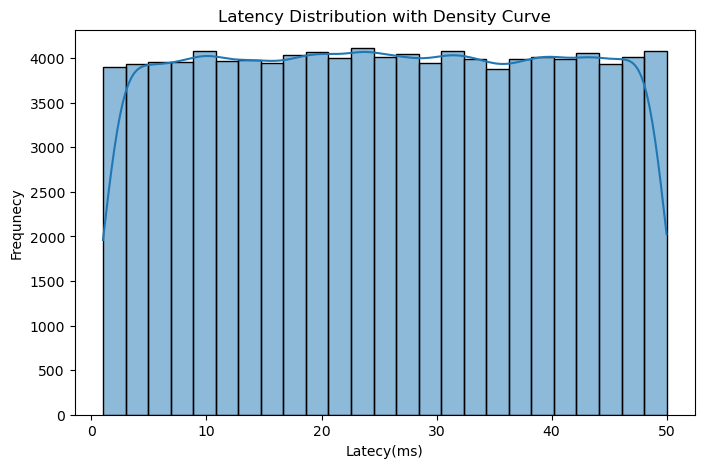

In [12]:
#1) Latency Distribution
plt.figure(figsize = (8,5))
sns.histplot(df['Network_Latency_ms'],kde=True,bins=25)
plt.title('Latency Distribution with Density Curve')
plt.xlabel('Latecy(ms)')
plt.ylabel('Frequnecy')
plt.show()

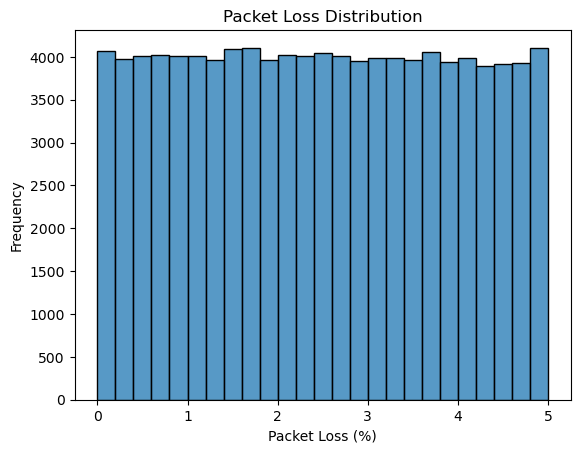

In [13]:
# 2. Packet Loss Distibution

plt.figure()
sns.histplot(df['Packet_Loss'],bins=25)
plt.xlabel("Packet Loss (%)")
plt.ylabel("Frequency")
plt.title("Packet Loss Distribution")
plt.show()

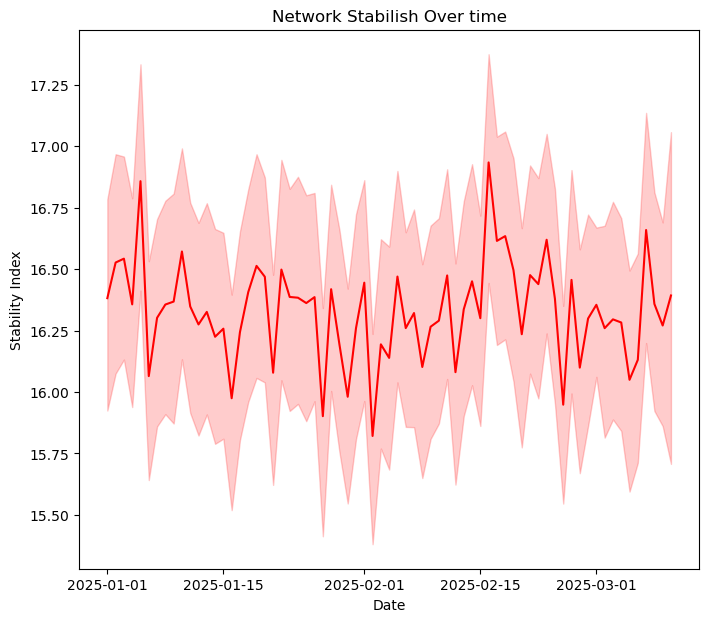

In [14]:
# Stability Trend 
plt.figure(figsize=(8,7))
sns.lineplot(x = 'Date',y = 'Network_Stability_Index',data=df,markers='o',color = 'r')
plt.title('Network Stabilish Over time')
plt.xlabel("Date")
plt.ylabel("Stability Index")
plt.show()

##### NETWORK vs EFFICIENCY

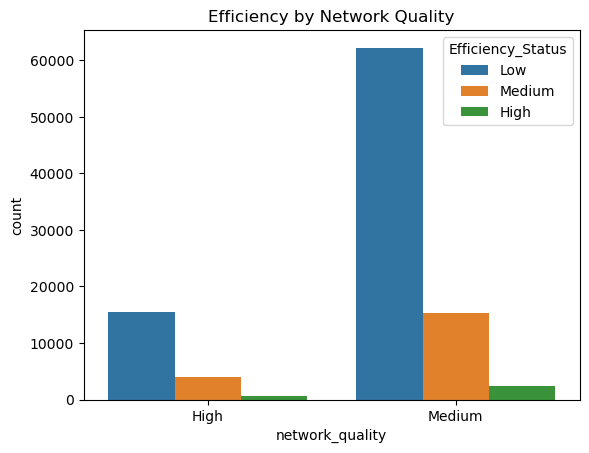

In [15]:
plt.figure()
sns.countplot(x = 'network_quality',hue='Efficiency_Status',data=df)
plt.title('Efficiency by Network Quality')
plt.show()

D:\Income taxt\gst\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


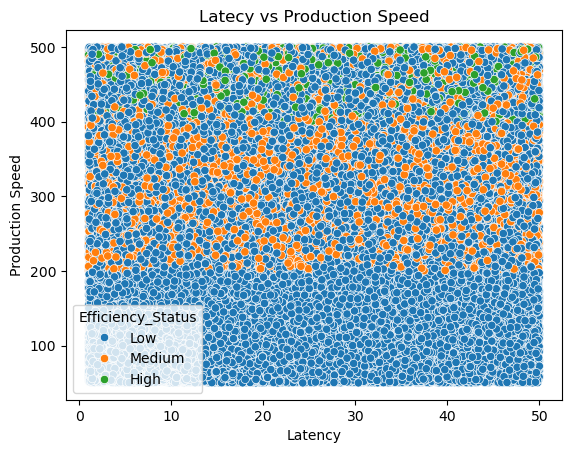

In [16]:
# Latency vs Production
plt.figure()
sns.scatterplot(x = 'Network_Latency_ms',y = 'Production_Speed_units_per_hr',hue='Efficiency_Status',data=df)
plt.title('Latecy vs Production Speed')
plt.xlabel("Latency")
plt.ylabel("Production Speed")
plt.show()

C:\Users\Harsh\AppData\Local\Temp\ipykernel_33416\421879491.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


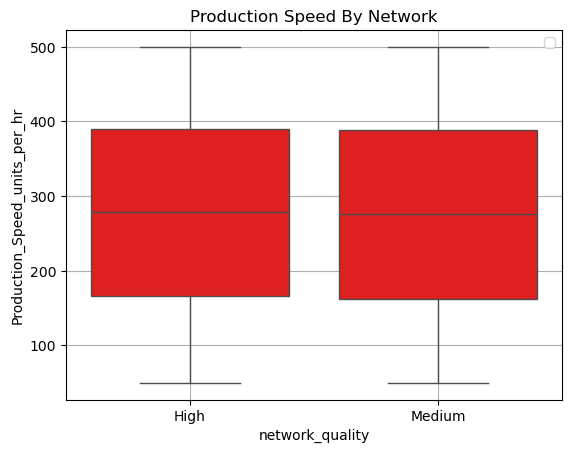

In [17]:
#Sensitive Zones
plt.figure()
sns.boxplot(x ='network_quality',y = 'Production_Speed_units_per_hr',data=df,color='r')
plt.title('Production Speed By Network')
plt.legend()
plt.grid()
plt.show()

##### Latency Impact Diagnostics

C:\Users\Harsh\AppData\Local\Temp\ipykernel_33416\1770216183.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  latency_group = df.groupby(pd.cut(df['Network_Latency_ms'], bins=5))['Production_Speed_units_per_hr'].mean()


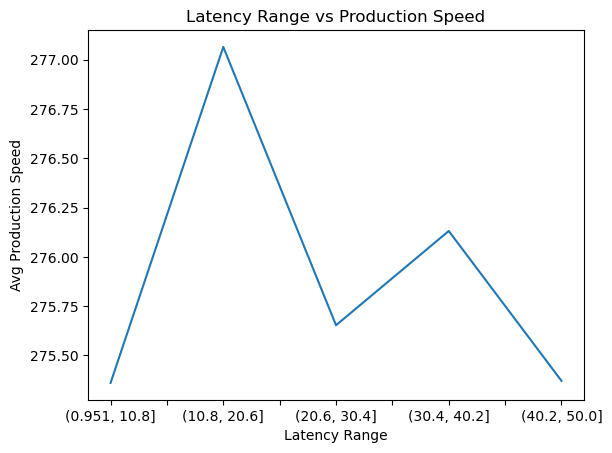

In [18]:
#Latency vs Production Trend
latency_group = df.groupby(pd.cut(df['Network_Latency_ms'], bins=5))['Production_Speed_units_per_hr'].mean()
latency_group.plot(kind='line')
plt.title("Latency Range vs Production Speed")
plt.xlabel("Latency Range")
plt.ylabel("Avg Production Speed")
plt.show()

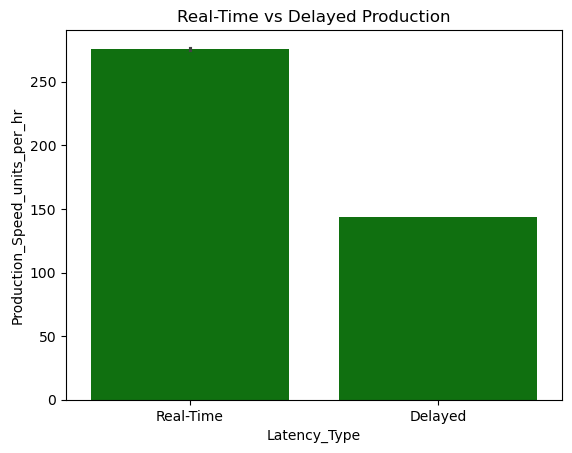

In [19]:
# Real-time vs Delay
df['Latency_Type'] = np.where(df['Network_Latency_ms'] < 50,'Real-Time','Delayed')
plt.figure()
sns.barplot(x = 'Latency_Type',y = 'Production_Speed_units_per_hr',data=df,color='g')
plt.title('Real-Time vs Delayed Production')
plt.show()

##### PACKET LOSS IMPACT DIAGNOSTICS

##### Packet loss impact Diagnosist

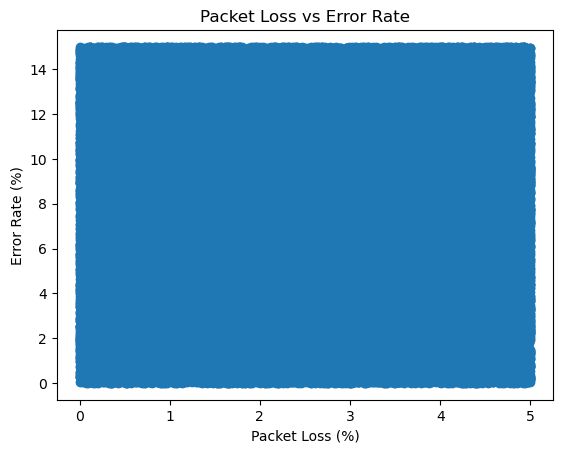

In [20]:
# Packet Loss vs error rate 
plt.figure()
plt.scatter(df['Packet_Loss'], df['Error_Rate'])
plt.title("Packet Loss vs Error Rate")
plt.xlabel("Packet Loss (%)")
plt.ylabel("Error Rate (%)")
plt.show()

D:\Income taxt\gst\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


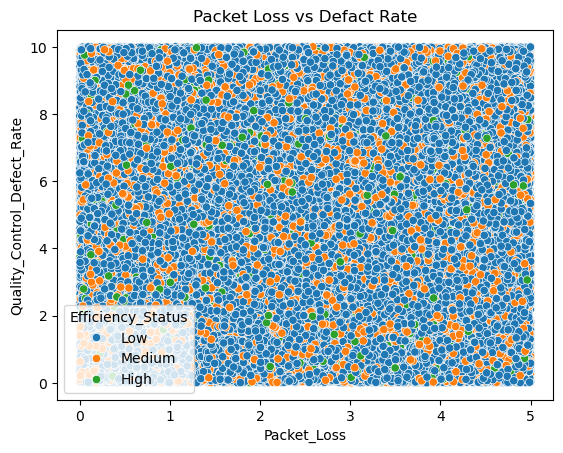

In [21]:
#Packet Loss vs Defect Rate
plt.figure()
sns.scatterplot(x = 'Packet_Loss',y = 'Quality_Control_Defect_Rate',hue='Efficiency_Status',data=df)
plt.title('Packet Loss vs Defact Rate')
plt.show()

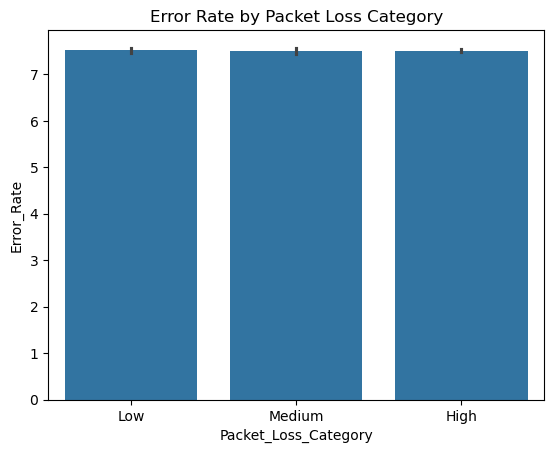

In [22]:
# Category - Based Analysis
df['Packet_Loss_Category'] = pd.cut(df['Packet_Loss'],bins=[0,1,2,5],labels=['Low','Medium','High'])

plt.figure()
sns.barplot(x = "Packet_Loss_Category", y = 'Error_Rate',data=df)
plt.title('Error Rate by Packet Loss Category')
plt.show()

##### Operation Mode Interaction Analysis


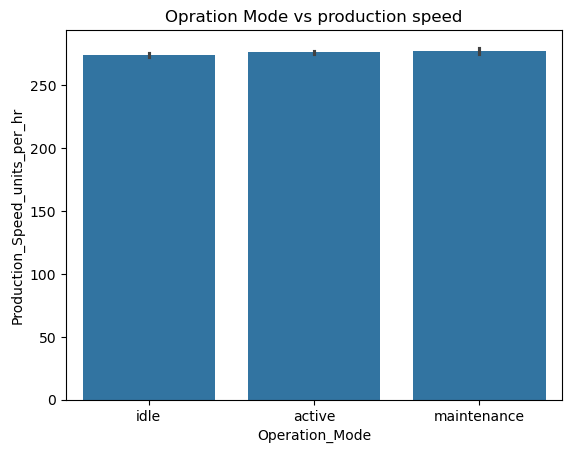

In [23]:
# mode vs Production
plt.figure()
sns.barplot(x = 'Operation_Mode', y = 'Production_Speed_units_per_hr',data=df)
plt.title('Opration Mode vs production speed')
plt.show()

<Figure size 640x480 with 0 Axes>

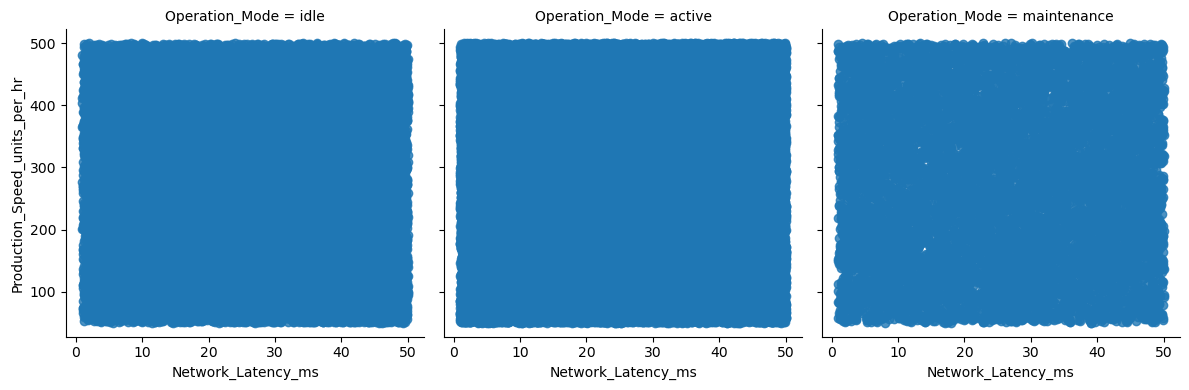

In [29]:
# Mode Sensitivity
plt.figure()
sns.lmplot(x = 'Network_Latency_ms', y='Production_Speed_units_per_hr',col='Operation_Mode',data=df,height=4,aspect=1)
plt.show()

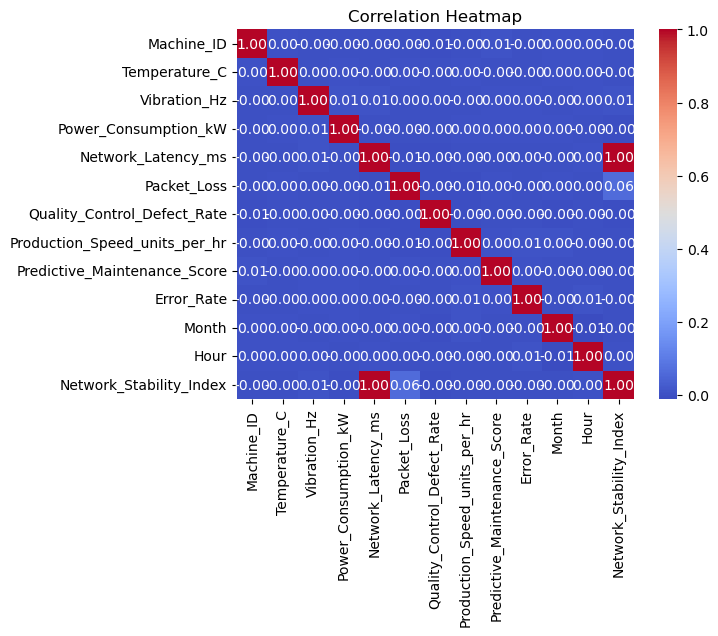

In [31]:
# Correlation Heatmap
plt.figure()
corr  = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,fmt=".2f",cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

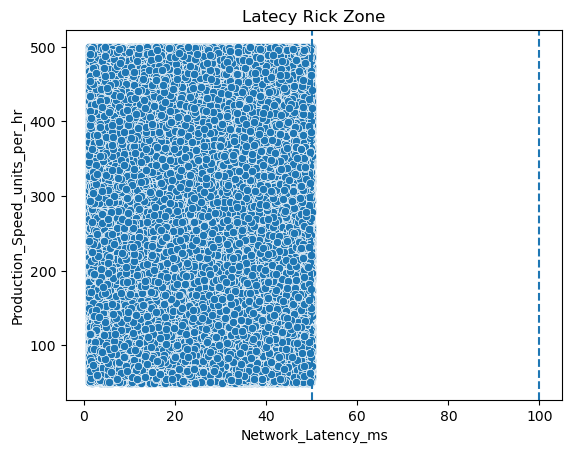

In [32]:
# latancy  Rick Zone
plt.figure()

sns.scatterplot(x='Network_Latency_ms',y = 'Production_Speed_units_per_hr',data=df)
plt.axvline(50,linestyle = '--')
plt.axvline(100,linestyle = '--')
plt.title('Latecy Rick Zone')
plt.show()

In [39]:
df.head()

,Date,Timestamp,Machine_ID,Operation_Mode,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss,Quality_Control_Defect_Rate,...,Predictive_Maintenance_Score,Error_Rate,Efficiency_Status,Month,Month_Name,Hour,Network_Stability_Index,network_quality,Latency_Type,Packet_Loss_Category
0,2025-01-01,00:00:00,39,idle,74.138,3.501,8.612,10.651,0.208,7.751,...,0.345,14.965,Low,1,January,0,6.4738,High,Real-Time,Low
1,2025-01-01,00:01:00,29,active,84.265,3.356,2.269,29.112,2.228,4.989,...,0.770,7.678,Low,1,January,0,18.3584,Medium,Real-Time,High
2,2025-01-01,00:02:00,15,active,44.280,2.080,6.144,18.357,1.639,0.457,...,0.987,8.198,Low,1,January,0,11.6698,Medium,Real-Time,Medium
3,2025-01-01,00:03:00,43,active,40.569,0.298,4.068,29.154,1.161,4.583,...,0.983,2.741,Medium,1,January,0,17.9568,Medium,Real-Time,Medium
4,2025-01-01,00:04:00,8,idle,75.064,0.346,6.226,34.029,4.797,2.288,...,0.573,12.101,Low,1,January,0,22.3362,Medium,Real-Time,High


In [43]:
df.to_csv(r"C:\united_inteship\Un_project\network_performance.csv", index=False)